In [2]:
import numpy as np
from suncalc import get_position
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely import coverage_union_all
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shadow_service import ShadowService

### Test class ShadowService

In [3]:
def plot_shadows_and_buildings(buildings: gpd.GeoDataFrame, shadows: gpd.GeoDataFrame, dt: pd.Timestamp, whole_day=False):
    fig, ax = plt.subplots(figsize=(12, 12))

    # --- Plot shadows ---
    if len(shadows) > 0:
        shadows.plot(ax=ax, color="#555555", alpha=0.4)

    # --- Plot buildings ---
    buildings.plot(
        ax=ax,
        color="#3a86ff",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
    )

    # --- Legend ---
    legend_handles = [
        mpatches.Patch(color="#3a86ff", alpha=0.8, label="Buildings"),
        mpatches.Patch(color="#555555", alpha=0.4, label="Ground Shadow"),
    ]

    ax.legend(handles=legend_handles, loc="upper right")

    ax.set_title(f"Building Shadow {dt.strftime('%Y-%m-%d %H:%M')}", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()

    plt.show()

In [4]:
lat_min = 52.13736
lat_max = 52.15098
lon_min = 11.63857
lon_max = 11.66323
bbox = (lon_min, lat_min, lon_max, lat_max)

#shadow_service = ShadowService(bbox)
shadow_service = ShadowService(None)

dt = pd.to_datetime('2026-06-05 9:41').tz_localize('Europe/Berlin')
shadow_map = shadow_service.get_shadow_map(dt)


In [5]:
shadow_map.to_file("./data/shadow_map_magdeburg.fgb", driver="FlatGeobuf")

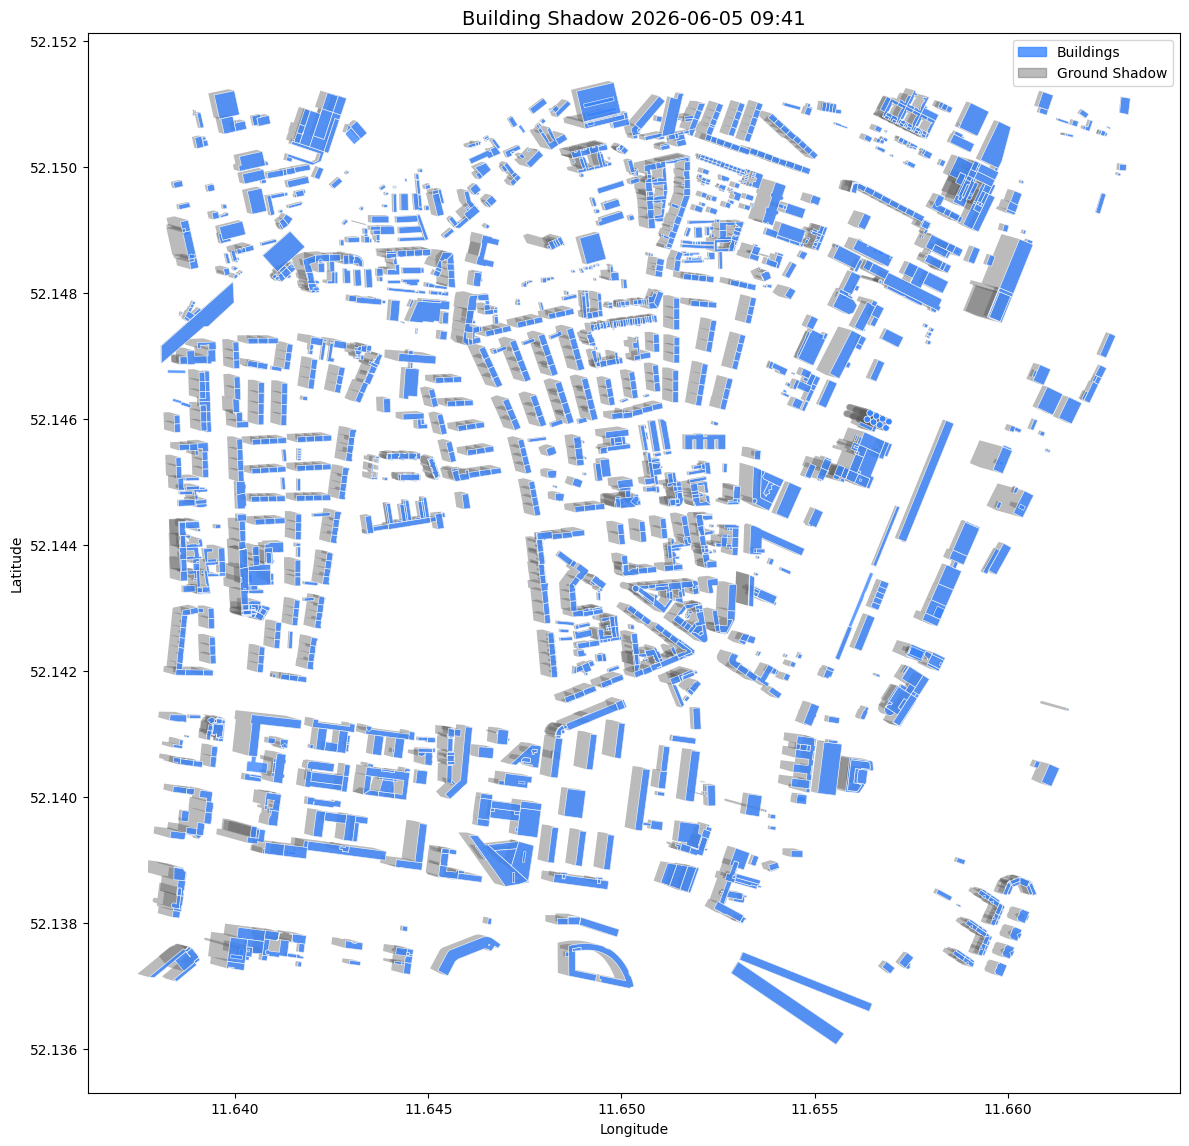

In [ ]:
plot_shadows_and_buildings(shadow_service.buildings, shadow_map, dt)

In [5]:
shadow_service.buildings

,building_id,height,original_building_id,geometry
0,79,41.0,DEST_DESTGEOT00002gaG,"POLYGON ((11.66157 52.14141, 11.66159 52.14137..."
1,7912,9.0,DEST_DESTLIKA0003B222,"POLYGON ((11.66192 52.14625, 11.66166 52.14592..."
2,8071,5.0,DEST_DESTLIKA0003B23L,"POLYGON ((11.66197 52.1463, 11.66192 52.14632,..."
3,8074,5.5,DEST_DESTLIKA0003B23M,"POLYGON ((11.66279 52.14732, 11.66255 52.14697..."
4,8069,3.5,DEST_DESTLIKA0003B23L,"POLYGON ((11.66221 52.1466, 11.66219 52.1466, ..."
...,...,...,...,...
2538,29341,13.0,DEST_DESTLIKA0003SPtv,"POLYGON ((11.64739 52.13862, 11.64759 52.13866..."
2539,29291,8.0,DEST_DESTLIKA0003SPtd,"POLYGON ((11.64662 52.13797, 11.64654 52.13798..."
2540,29289,12.0,DEST_DESTLIKA0003SPtA,"POLYGON ((11.64665 52.13776, 11.64688 52.13766..."
2541,29288,3.0,DEST_DESTLIKA0003SPtA,"POLYGON ((11.6466 52.13765, 11.64659 52.13763,..."


### Combine trees info with buildings

In [6]:
trees = gpd.read_file("trees_ovgu.fgb")

In [10]:
trees = trees.rename(columns={"height_m": "height"})
output_file = "trees_ovgu.fgb"
trees.to_file(output_file, driver="FlatGeobuf")

In [14]:
trees_4326 = trees.copy()
trees_4326 = trees_4326.to_crs(4326)

In [15]:
trees_4326.to_file("trees_ovgu_4326.fgb", driver="FlatGeobuf")

In [26]:
lat_min = 52.137663
lat_max = 52.145538
lon_min = 11.639779
lon_max = 11.652739
ovgu_bbox = (lon_min, lat_min, lon_max, lat_max)

buildings_ovgu = gpd.read_file("./data/buildings.fgb", bbox=ovgu_bbox)

In [27]:
# Select and rename relevant columns
buildings_clean = buildings_ovgu[["original_building_id", "height", "geometry"]].rename(
    columns={"original_building_id": "id"}
)

trees_clean = trees_4326[["tree_id", "height", "geometry"]].rename(
    columns={"tree_id": "id"}
)

# Merge into a single GeoDataFrame
merged = gpd.GeoDataFrame(
    pd.concat([buildings_clean, trees_clean], ignore_index=True),
    geometry="geometry",
    crs=buildings_ovgu.crs
)

In [29]:
merged.to_file("merged_buildings_trees.fgb", driver="FlatGeobuf")

In [33]:
import pybdshadow

merged_processed = pybdshadow.bd_preprocess(merged, height="height")
merged_processed

,id,height,geometry,building_id
0,DEST_DESTLIKA0003MHwJ,18.000000,"POLYGON ((11.64033 52.14367, 11.64033 52.14365...",0
1,DEST_DESTLIKA0003MHwJ,18.500000,"POLYGON ((11.64033 52.14367, 11.64034 52.14367...",1
2,DEST_DESTLIKA0003MHBv,4.000000,"POLYGON ((11.64036 52.14341, 11.64035 52.14354...",2
3,DEST_DESTLIKA0003MHBv,2.500000,"POLYGON ((11.64031 52.14354, 11.64032 52.1434,...",3
4,DEST_DESTLIKA0003MHBv,26.500000,"POLYGON ((11.64015 52.14328, 11.64014 52.14341...",4
...,...,...,...,...
2165,52,10.017620,"POLYGON ((11.64124 52.13824, 11.64128 52.13823...",2141
2166,57,4.366145,"POLYGON ((11.64078 52.13796, 11.64079 52.13796...",2142
2167,58,6.594542,"POLYGON ((11.64119 52.13795, 11.6412 52.13795,...",2143
2168,56,8.168310,"POLYGON ((11.6409 52.13797, 11.64092 52.13797,...",2144


In [34]:
merged_processed.to_file("buildings_trees_processed.fgb", driver="FlatGeobuf")

### Test Buildings and Trees with ShadowService class

In [3]:
shadow_service = ShadowService(None, buildings_path="buildings_trees_processed.fgb")

dt = pd.to_datetime('2026-06-09 9:33').tz_localize('Europe/Berlin')
shadow_map = shadow_service.get_shadow_map(dt)

In [7]:
def plot_shadows_and_buildings_trees(buildings: gpd.GeoDataFrame, shadows: gpd.GeoDataFrame, dt: pd.Timestamp, whole_day=False):
    fig, ax = plt.subplots(figsize=(12, 12))

    # --- Split buildings and trees by id pattern ---
    is_tree = buildings["id"].astype(str).str.match(r"^\d+$")
    trees_gdf = buildings[is_tree]
    buildings_gdf = buildings[~is_tree]

    # --- Plot shadows ---
    if len(shadows) > 0:
        shadows.plot(ax=ax, color="#555555", alpha=0.4)

    # --- Plot buildings ---
    if len(buildings_gdf) > 0:
        buildings_gdf.plot(ax=ax, color="#3a86ff", alpha=0.8, edgecolor="white", linewidth=0.5)

    # --- Plot trees ---
    if len(trees_gdf) > 0:
        trees_gdf.plot(ax=ax, color="#2dc653", alpha=0.8, edgecolor="white", linewidth=0.5)

    # --- Legend ---
    legend_handles = [
        mpatches.Patch(color="#3a86ff", alpha=0.8, label="Buildings"),
        mpatches.Patch(color="#2dc653", alpha=0.8, label="Trees"),
        mpatches.Patch(color="#555555", alpha=0.4, label="Ground Shadow"),
    ]

    ax.legend(handles=legend_handles, loc="upper right")
    ax.set_title(f"Building Shadow {dt.strftime('%Y-%m-%d %H:%M')}", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()

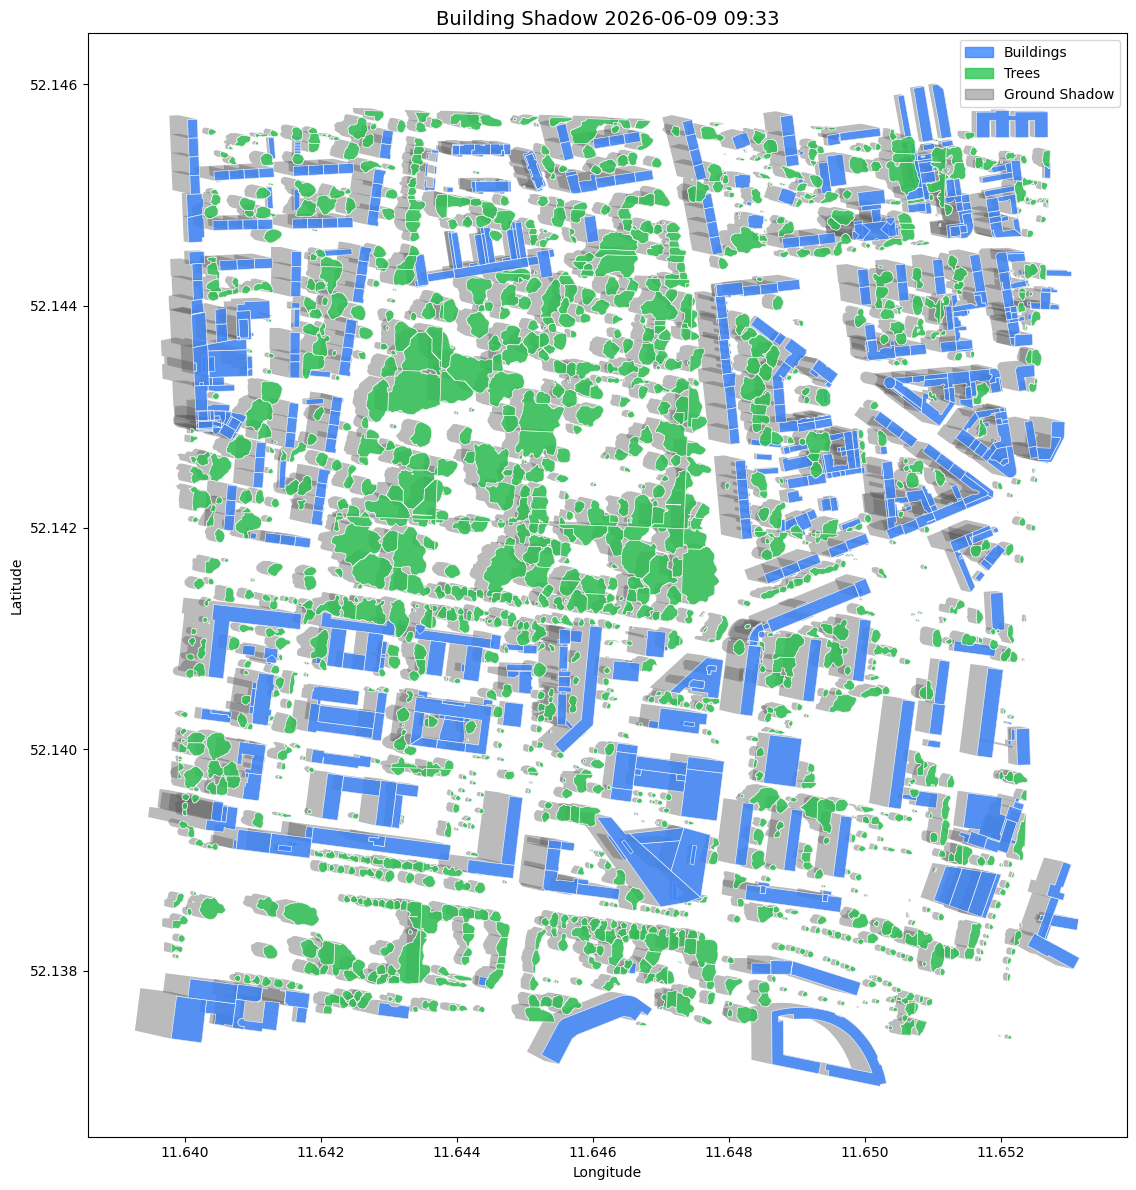

In [8]:
plot_shadows_and_buildings_trees(shadow_service.buildings, shadow_map, dt)